# Plane-Wave Atom-Slice Gaussian Benchmark

This notebook benchmarks the one-size Gaussian action update on a high-count plane-wave atom-slice example. A near-plane wave is represented by about 50,000 Gaussian beams, propagated through a thin projected Au atom slice, and compared with a grid/Fresnel reference.

The Gaussian method uses the same idea as the unified correction notebook: sample the local action over each Gaussian support, fit the best quadratic action, update the Gaussian, then propagate analytically. For speed, the atom-slice action is first rasterized on the reference grid and each Gaussian samples that action grid by bilinear interpolation.

The propagation distance is set longer than the small diagnostic examples so the diffraction structure is easier to see.

## Setup

The defaults are intentionally set for a serious GPU benchmark. If the first compile is too heavy, reduce `TARGET_GAUSSIANS` to `10_000` and then scale back up.

In [ ]:
import os
import time
from functools import partial

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.85")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np

from temgym_core.components import Detector
from temgym_core.evaluate import evaluate_gaussians_fast
from temgym_core.gaussian import GaussianBeam, propagate_free_space_jit
from temgym_core.gaussian_corrections import (
    apply_fitted_quadratic_action,
    concatenate_gaussian_beams,
    sampled_quadratic_residual_on_beam,
)
from temgym_core.potential import potential_smoothed_from_r2
from temgym_core.source import square_input_wave
from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)

TARGET_GAUSSIANS = 100_000
GRID_SHAPE = 128
ATOM_GRID_SIDE = 5
GRID_MARGIN = 8.0  # A, half-window margin outside the atom patch
SLICE_THICKNESS = 0.02  # A
PROPAGATION_DISTANCE = 3.0  # A; increase for stronger Fresnel diffraction
BEAM_OVERLAP = 2.4
CHUNK_SIZE = 2048
FIT_SUPPORT_RADIUS = 1.0
FIT_SAMPLES_PER_AXIS = 7
FIT_WEIGHT_POWER = 1.0  # Gaussian-weighted fit; set to None for an unweighted fit
FIT_RESIDUAL_TARGET_RAD = 0.25
FIT_RESIDUAL_DIAGNOSTIC_SAMPLES = 512
WARM_REPEATS = 1
EVAL_METHOD = "auto"  # "auto" uses the GPU/Pallas Gaussian evaluator when available
DISPLAY_CROP_FRACTION = 0.5  # central fraction shown in real-space/FFT plots

print("JAX backend:", jax.default_backend())

%matplotlib widget

JAX backend: gpu


## Shared Helpers

In [ ]:
AU_LOBATO = jnp.array(
    [
        [
            1.6759346706487,
            3.00486602969729,
            0.595340013161635,
            0.0117163186623094,
            4.296782976398e-05,
        ],
        [
            5.52231093211402,
            1.38007223007196,
            0.162229237655945,
            0.00901814890416575,
            0.00037927766747767,
        ],
    ],
    dtype=jnp.float64,
)


def block_until_ready(value):
    def block_leaf(x):
        return x.block_until_ready() if hasattr(x, "block_until_ready") else x

    return jax.tree_util.tree_map(block_leaf, value)


def timed_call(fn):
    t0 = time.perf_counter()
    value = fn()
    block_until_ready(value)
    return value, time.perf_counter() - t0


def beam_count(beam: GaussianBeam) -> int:
    return int(np.asarray(beam.to_vector().x).size)


def aligned_field_error(test, ref) -> float:
    alpha = jnp.vdot(test, ref) / jnp.vdot(test, test)
    return float(jnp.linalg.norm(alpha * test - ref) / jnp.linalg.norm(ref))


def normalized_intensity_error(test, ref) -> float:
    test_i = jnp.abs(test) ** 2
    ref_i = jnp.abs(ref) ** 2
    test_i = test_i / jnp.sum(test_i)
    ref_i = ref_i / jnp.sum(ref_i)
    return float(jnp.linalg.norm(test_i - ref_i) / jnp.linalg.norm(ref_i))


def atom_plane(n_side, spacing):
    if n_side == 1:
        return jnp.array([[0.0, 0.0, 0.0]], dtype=jnp.float64)
    axis = (jnp.arange(n_side, dtype=jnp.float64) - 0.5 * (n_side - 1)) * spacing
    xx, yy = jnp.meshgrid(axis, axis, indexing="ij")
    return jnp.stack(
        (xx.ravel(), yy.ravel(), jnp.zeros((n_side * n_side,), dtype=jnp.float64)),
        axis=-1,
    )


def multi_atom_action(xy, z, sigma, k, atom_xyz, dz, cutoff_radius, element_params):
    def one_atom(atom):
        r2 = (
            (xy[0] - atom[0]) ** 2
            + (xy[1] - atom[1]) ** 2
            + (z - atom[2]) ** 2
        )
        return potential_smoothed_from_r2(r2, element_params, cutoff_radius)

    potential = jnp.sum(jax.vmap(one_atom)(atom_xyz))
    return -(sigma / k) * potential * dz


def evaluate_field(beam, grid):
    return evaluate_gaussians_fast(
        beam.to_vector(),
        grid,
        method=EVAL_METHOD,
        tile_pixels=64,
        tile_beams=16,
    )


def central_crop(data, extent, fraction=DISPLAY_CROP_FRACTION):
    if not (0.0 < fraction <= 1.0):
        raise ValueError("`fraction` must be in (0, 1].")
    n_y, n_x = data.shape[-2:]
    crop_x = max(1, int(round(n_x * fraction)))
    crop_y = max(1, int(round(n_y * fraction)))
    x0 = (n_x - crop_x) // 2
    y0 = (n_y - crop_y) // 2
    x_slice = slice(x0, x0 + crop_x)
    y_slice = slice(y0, y0 + crop_y)
    x_min, x_max, y_min, y_max = extent
    dx = (x_max - x_min) / n_x
    dy = (y_max - y_min) / n_y
    crop_extent = (
        x_min + x0 * dx,
        x_min + (x0 + crop_x) * dx,
        y_min + y0 * dy,
        y_min + (y0 + crop_y) * dy,
    )
    return data[y_slice, x_slice], crop_extent, y_slice, x_slice


def complex_phase_rgb(field):
    phase = (np.angle(field) + np.pi) / (2.0 * np.pi)
    amp = np.abs(field)
    value = amp / np.maximum(np.percentile(amp, 99.5), 1e-30)
    value = np.clip(value, 0.0, 1.0)
    hsv = np.stack((phase, np.ones_like(value), value), axis=-1)
    return hsv_to_rgb(hsv)

## Build Plane Wave And Atom Slice

In [ ]:
def make_plane_wave_case():
    spacing = 4.078 / np.sqrt(2.0)  # Au fcc [001]-like projected spacing, A
    atom_xyz = atom_plane(ATOM_GRID_SIDE, spacing)
    extent = 0.5 * max(ATOM_GRID_SIDE - 1, 0) * spacing + GRID_MARGIN
    pixel = 2.0 * extent / GRID_SHAPE
    grid = Detector(z=0.0, pixel_size=(pixel, pixel), shape=(GRID_SHAPE, GRID_SHAPE))

    beams_side = int(np.ceil(np.sqrt(TARGET_GAUSSIANS)))
    aperture_length = 2.0 * extent
    waist = aperture_length * BEAM_OVERLAP / beams_side
    beam = square_input_wave(
        aperture_length=aperture_length,
        waist=waist,
        voltage=200e3,
        overlap_factor=BEAM_OVERLAP,
        wavelength_unit="angstrom",
    ).to_vector()
    return grid, beam, atom_xyz, extent, waist


@partial(jax.jit, static_argnames=("shape",))
def build_atom_action_grid(coords, shape, z, sigma, k, atom_xyz, dz, cutoff_radius, element_params):
    action = jax.vmap(
        lambda xy: multi_atom_action(
            xy,
            z,
            sigma,
            k,
            atom_xyz,
            dz,
            cutoff_radius,
            element_params,
        )
    )(coords)
    return action.reshape(shape)


grid, input_beam, atom_xyz, extent, waist = make_plane_wave_case()
vector = input_beam.to_vector()
action_grid, t_action_grid = timed_call(
    lambda: build_atom_action_grid(
        grid.coords,
        grid.shape,
        vector.z[0],
        vector.sigma[0],
        vector.k[0],
        atom_xyz,
        SLICE_THICKNESS,
        grid.pixel_size[0] / 3.0,
        AU_LOBATO,
    )
)

print(f"grid={grid.shape}, pixel={grid.pixel_size[0]:.4f} A")
print(f"atoms={atom_xyz.shape[0]}, beams={beam_count(input_beam)}, waist={waist:.4f} A")
print(f"slice thickness={SLICE_THICKNESS:.4f} A, propagation={PROPAGATION_DISTANCE:.1f} A")
print(f"action grid build={t_action_grid:.4f} s")

grid=(128, 128), pixel=0.2151 A
atoms=25, beams=100489, waist=0.2085 A
slice thickness=0.0200 A, propagation=3.0 A
action grid build=0.6386 s


## Gaussian Fitted-Action Propagation

In [ ]:
def bilinear_sample(image, xy, x0, y0, step_x, step_y):
    h, w = image.shape
    px = (xy[0] - x0) / step_x
    py = (xy[1] - y0) / step_y
    px = jnp.clip(px, 0.0, w - 1.0)
    py = jnp.clip(py, 0.0, h - 1.0)

    ix0 = jnp.floor(px).astype(jnp.int32)
    iy0 = jnp.floor(py).astype(jnp.int32)
    ix1 = jnp.minimum(ix0 + 1, w - 1)
    iy1 = jnp.minimum(iy0 + 1, h - 1)
    wx = px - ix0
    wy = py - iy0

    v00 = image[iy0, ix0]
    v10 = image[iy0, ix1]
    v01 = image[iy1, ix0]
    v11 = image[iy1, ix1]
    return (
        (1.0 - wx) * (1.0 - wy) * v00
        + wx * (1.0 - wy) * v10
        + (1.0 - wx) * wy * v01
        + wx * wy * v11
    )


def diagnostic_indices(sample_count=FIT_RESIDUAL_DIAGNOSTIC_SAMPLES, atom_neighbour_count=8):
    vector_all = input_beam.to_vector()
    n = beam_count(vector_all)
    stride = max(1, n // sample_count)
    uniform = np.arange(0, n, stride, dtype=np.int32)[:sample_count]

    centers = np.asarray(vector_all.r_xy)
    atoms_xy = np.asarray(atom_xyz[:, :2])
    d2 = np.sum((centers[:, None, :] - atoms_xy[None, :, :]) ** 2, axis=-1)
    nearest = np.argsort(np.min(d2, axis=1))[: min(n, atom_neighbour_count * atoms_xy.shape[0])]
    return np.unique(np.concatenate((uniform, nearest))).astype(np.int32)


@partial(jax.jit, static_argnames=("fit_support_radius", "fit_samples_per_axis", "fit_weight_power"))
def apply_fitted_action_grid_to_vector(
    vector,
    action_grid,
    x0,
    y0,
    step_x,
    step_y,
    fit_support_radius,
    fit_samples_per_axis,
    fit_weight_power,
):
    def one_ray(ray):
        return apply_fitted_quadratic_action(
            ray,
            lambda xy: bilinear_sample(action_grid, xy, x0, y0, step_x, step_y),
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
            fit_weight_power=fit_weight_power,
        )

    return jax.vmap(one_ray)(vector)


def beam_chunks(beam, chunk_size):
    vector = beam.to_vector()
    n = beam_count(vector)
    for start in range(0, n, chunk_size):
        yield vector[start : min(start + chunk_size, n)]


def concat_chunks(chunks):
    if len(chunks) == 1:
        return chunks[0].to_vector()
    return concatenate_gaussian_beams(chunks).to_vector()


def apply_fitted_action_grid_chunked(
    beam,
    action_grid,
    grid,
    *,
    fit_support_radius=FIT_SUPPORT_RADIUS,
    fit_samples_per_axis=FIT_SAMPLES_PER_AXIS,
    fit_weight_power=FIT_WEIGHT_POWER,
):
    x_coords, y_coords = grid.coords_1d
    x0 = x_coords[0]
    y0 = y_coords[0]
    step_x = x_coords[1] - x_coords[0]
    step_y = y_coords[1] - y_coords[0]
    chunks = []
    for chunk in beam_chunks(beam, CHUNK_SIZE):
        out = apply_fitted_action_grid_to_vector(
            chunk,
            action_grid,
            x0,
            y0,
            step_x,
            step_y,
            fit_support_radius,
            fit_samples_per_axis,
            fit_weight_power,
        )
        chunks.append(block_until_ready(out.to_vector()))
    return concat_chunks(chunks)


def propagate_chunked(beam, distance):
    chunks = []
    for chunk in beam_chunks(beam, CHUNK_SIZE):
        chunks.append(block_until_ready(propagate_free_space_jit(chunk, distance).to_vector()))
    return concat_chunks(chunks)


@jax.jit
def reference_step(input_field, action_grid, pixel_size, wavelength, k, propagation_distance):
    transmitted = input_field * jnp.exp(1j * k * action_grid)
    return FresnelPropagator(
        transmitted,
        L=pixel_size * input_field.shape[0],
        wavelength=wavelength,
        z=propagation_distance,
    )


def action_sampling_diagnostic(sample_count=512):
    vector_all = input_beam.to_vector()
    indices = diagnostic_indices(sample_count)
    points = vector_all[jnp.asarray(indices)].r_xy
    x_coords, y_coords = grid.coords_1d
    x0 = x_coords[0]
    y0 = y_coords[0]
    step_x = x_coords[1] - x_coords[0]
    step_y = y_coords[1] - y_coords[0]
    sampled = jax.vmap(
        lambda xy: bilinear_sample(action_grid, xy, x0, y0, step_x, step_y)
    )(points)
    direct = jax.vmap(
        lambda xy: multi_atom_action(
            xy,
            vector.z[0],
            vector.sigma[0],
            vector.k[0],
            atom_xyz,
            SLICE_THICKNESS,
            grid.pixel_size[0] / 3.0,
            AU_LOBATO,
        )
    )(points)
    phase_error = vector.k[0] * (sampled - direct)
    return {
        "sample_count": int(points.shape[0]),
        "step_x": float(step_x),
        "step_y": float(step_y),
        "rms_phase_error_rad": float(jnp.sqrt(jnp.mean(phase_error**2))),
        "max_phase_error_rad": float(jnp.max(jnp.abs(phase_error))),
    }


@partial(jax.jit, static_argnames=("fit_support_radius", "fit_samples_per_axis", "fit_weight_power"))
def fitted_residuals_for_vector(
    vector,
    action_grid,
    x0,
    y0,
    step_x,
    step_y,
    fit_support_radius,
    fit_samples_per_axis,
    fit_weight_power,
):
    def one_ray(ray):
        residual = sampled_quadratic_residual_on_beam(
            lambda xy: bilinear_sample(action_grid, xy, x0, y0, step_x, step_y),
            ray,
            scale=ray.k,
            support_radius=FIT_SUPPORT_RADIUS,
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
            fit_weight_power=fit_weight_power,
        )
        return residual.max_abs, residual.rms

    return jax.vmap(one_ray)(vector)


def fitted_residual_diagnostic(
    sample_count=FIT_RESIDUAL_DIAGNOSTIC_SAMPLES,
    *,
    fit_support_radius=FIT_SUPPORT_RADIUS,
    fit_samples_per_axis=FIT_SAMPLES_PER_AXIS,
    fit_weight_power=FIT_WEIGHT_POWER,
):
    vector_all = input_beam.to_vector()
    sample = vector_all[jnp.asarray(diagnostic_indices(sample_count))]
    x_coords, y_coords = grid.coords_1d
    max_abs, rms = fitted_residuals_for_vector(
        sample,
        action_grid,
        x_coords[0],
        y_coords[0],
        x_coords[1] - x_coords[0],
        y_coords[1] - y_coords[0],
        fit_support_radius,
        fit_samples_per_axis,
        fit_weight_power,
    )
    max_abs_np = np.asarray(max_abs)
    rms_np = np.asarray(rms)
    return {
        "sample_count": int(max_abs_np.size),
        "fit_samples_per_axis": fit_samples_per_axis,
        "fit_support_radius": fit_support_radius,
        "fit_weight_power": fit_weight_power,
        "max_residual_p50_rad": float(np.percentile(max_abs_np, 50)),
        "max_residual_p90_rad": float(np.percentile(max_abs_np, 90)),
        "max_residual_p99_rad": float(np.percentile(max_abs_np, 99)),
        "max_residual_worst_rad": float(np.max(max_abs_np)),
        "rms_residual_mean_rad": float(np.mean(rms_np)),
    }

## Run Benchmark

The action-grid sampler diagnostic is printed first. `step_y` is usually negative because image row index and physical y run in opposite directions; the important values are the RMS and max phase interpolation errors in radians.

The fitted-quadratic residual diagnostic reports how much non-quadratic phase is left inside representative Gaussian supports after the sampled fit. The default fit is now a Gaussian-weighted 5x5 fit, which is a better accuracy default than the earlier unweighted 3x3 fit while keeping the same number of Gaussians.

The first run includes JAX compilation. The warm timings below are the better comparison once kernels are compiled.

In [ ]:
def run_once(
    *,
    fit_support_radius=FIT_SUPPORT_RADIUS,
    fit_samples_per_axis=FIT_SAMPLES_PER_AXIS,
    fit_weight_power=FIT_WEIGHT_POWER,
):
    input_field, t_input = timed_call(lambda: evaluate_field(input_beam, grid))
    reference, t_reference = timed_call(
        lambda: reference_step(
            input_field,
            action_grid,
            grid.pixel_size[0],
            vector.wavelength[0],
            vector.k[0],
            PROPAGATION_DISTANCE,
        )
    )
    fitted, t_fit = timed_call(
        lambda: apply_fitted_action_grid_chunked(
            input_beam,
            action_grid,
            grid,
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
            fit_weight_power=fit_weight_power,
        )
    )
    propagated, t_propagate = timed_call(
        lambda: propagate_chunked(fitted, PROPAGATION_DISTANCE)
    )
    gaussian_field, t_output_eval = timed_call(lambda: evaluate_field(propagated, grid))
    timings = {
        "input_gaussian_eval": t_input,
        "fresnel_reference_step": t_reference,
        "gaussian_fit_action": t_fit,
        "gaussian_propagate": t_propagate,
        "gaussian_output_eval": t_output_eval,
        "gaussian_state_path_total": t_fit + t_propagate,
        "gaussian_grid_comparison_total": t_fit + t_propagate + t_output_eval,
    }
    return reference, gaussian_field, propagated, timings


sampler_diagnostic = action_sampling_diagnostic()
print("Action-grid sampler diagnostic")
for key, value in sampler_diagnostic.items():
    print(f"{key:24s}: {value}")
if sampler_diagnostic["max_phase_error_rad"] > 0.25:
    print("warning: action-grid interpolation error is large; increase GRID_SHAPE before judging Gaussian propagation")
print()

residual_diagnostic = fitted_residual_diagnostic()
print("Fitted-quadratic residual diagnostic")
for key, value in residual_diagnostic.items():
    print(f"{key:24s}: {value}")
if residual_diagnostic["max_residual_p90_rad"] > FIT_RESIDUAL_TARGET_RAD:
    print("warning: many sampled Gaussians exceed the residual target; use a finer fit or local splitting near atoms")
print()

reference, gaussian_field, output_beam, first_timings = run_once()
warm_records = []
for _ in range(WARM_REPEATS):
    _, _, _, warm_timings = run_once()
    warm_records.append(warm_timings)

warm_timings = {
    key: min(record[key] for record in warm_records)
    for key in warm_records[0]
} if warm_records else {}

field_error = aligned_field_error(gaussian_field, reference)
intensity_error = normalized_intensity_error(gaussian_field, reference)

print(f"field_error={field_error:.4g}, intensity_error={intensity_error:.4g}")
print("First run timings")
for key, value in first_timings.items():
    print(f"{key:32s}: {value:8.4f} s")
if warm_timings:
    print("Warm timing best-of-repeat")
    for key, value in warm_timings.items():
        print(f"{key:32s}: {value:8.4f} s")
    print(
        "warm state_path / warm fresnel_step = "
        f"{warm_timings['gaussian_state_path_total'] / warm_timings['fresnel_reference_step']:.3g}"
    )
    print(
        "warm grid_comparison / warm fresnel_step = "
        f"{warm_timings['gaussian_grid_comparison_total'] / warm_timings['fresnel_reference_step']:.3g}"
    )

Action-grid sampler diagnostic
sample_count            : 710
step_x                  : 0.21511192042746075
step_y                  : -0.21511192042746075
rms_phase_error_rad     : 0.00033291204287180245
max_phase_error_rad     : 0.0016235022788264305

Fitted-quadratic residual diagnostic
sample_count            : 710
fit_samples_per_axis    : 5
fit_support_radius      : 1.0
fit_weight_power        : 1.0
max_residual_p50_rad    : 2.3840936673122788e-07
max_residual_p90_rad    : 0.0004408384789040668
max_residual_p99_rad    : 0.0006629435439006649
max_residual_worst_rad  : 0.0006716889322069507
rms_residual_mean_rad   : 4.355182753031283e-05

field_error=0.01718, intensity_error=0.009105
First run timings
input_gaussian_eval             :   0.0874 s
fresnel_reference_step          :   0.3565 s
gaussian_fit_action             :   4.0554 s
gaussian_propagate              :   0.5730 s
gaussian_output_eval            :   0.0867 s
gaussian_state_path_total       :   4.6284 s
gaussian_grid_com

## Real-Space Propagated Field

The longer propagation distance makes the atom-slice diffraction and phase contrast easier to see in real space.

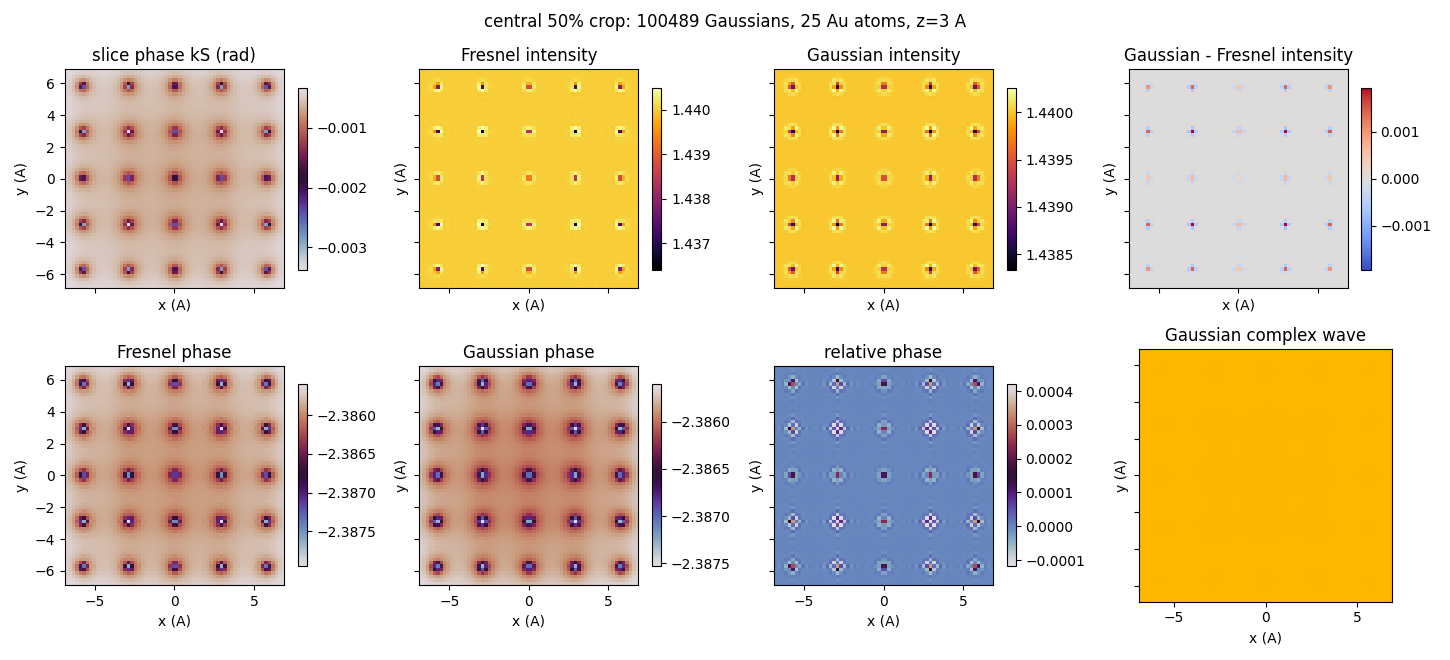

In [ ]:
reference_np = np.asarray(reference)
gaussian_np = np.asarray(gaussian_field)
action_np = np.asarray(action_grid)
full_extent = (-extent, extent, -extent, extent)

reference_crop, plot_extent, y_crop, x_crop = central_crop(reference_np, full_extent)
gaussian_crop, _, _, _ = central_crop(gaussian_np, full_extent)
action_crop, _, _, _ = central_crop(action_np, full_extent)

intensity_diff = np.abs(gaussian_crop) ** 2 - np.abs(reference_crop) ** 2
relative_phase = np.angle(gaussian_crop * np.conj(reference_crop))
slice_phase = np.asarray(vector.k[0]) * action_crop
diff_limit = float(np.max(np.abs(intensity_diff)))
atom_xy = np.asarray(atom_xyz)
visible_atoms = (
    (atom_xy[:, 0] >= plot_extent[0])
    & (atom_xy[:, 0] <= plot_extent[1])
    & (atom_xy[:, 1] >= plot_extent[2])
    & (atom_xy[:, 1] <= plot_extent[3])
)

fig, axes = plt.subplots(2, 4, figsize=(14.5, 6.6), sharex=True, sharey=True)
panels = [
    (slice_phase, "slice phase kS (rad)", "twilight", None),
    (np.abs(reference_crop) ** 2, "Fresnel intensity", "inferno", None),
    (np.abs(gaussian_crop) ** 2, "Gaussian intensity", "inferno", None),
    (intensity_diff, "Gaussian - Fresnel intensity", "coolwarm", diff_limit),
    (np.angle(reference_crop), "Fresnel phase", "twilight", None),
    (np.angle(gaussian_crop), "Gaussian phase", "twilight", None),
    (relative_phase, "relative phase", "twilight", None),
    (complex_phase_rgb(gaussian_crop), "Gaussian complex wave", None, None),
]
for ax, (data, title, cmap, limit) in zip(axes.ravel(), panels):
    kwargs = {}
    if limit is not None and limit > 0:
        kwargs.update(vmin=-limit, vmax=limit)
    if cmap is None:
        im = ax.imshow(data, extent=plot_extent, origin="lower")
    else:
        im = ax.imshow(data, extent=plot_extent, origin="lower", cmap=cmap, **kwargs)
        fig.colorbar(im, ax=ax, shrink=0.72)
    ax.set_title(title)
    ax.set_xlabel("x (A)")
    ax.set_ylabel("y (A)")
fig.suptitle(
    f"central {DISPLAY_CROP_FRACTION:.0%} crop: {beam_count(input_beam)} Gaussians, "
    f"{atom_xyz.shape[0]} Au atoms, z={PROPAGATION_DISTANCE:g} A"
)
fig.tight_layout()
plt.show()

## Diffraction View

This FFT power plot is not the propagation algorithm; it is just a compact way to inspect the diffraction content in the propagated fields. It uses the same central crop and a Hann window so the square-wave boundary does not dominate the diffraction view.

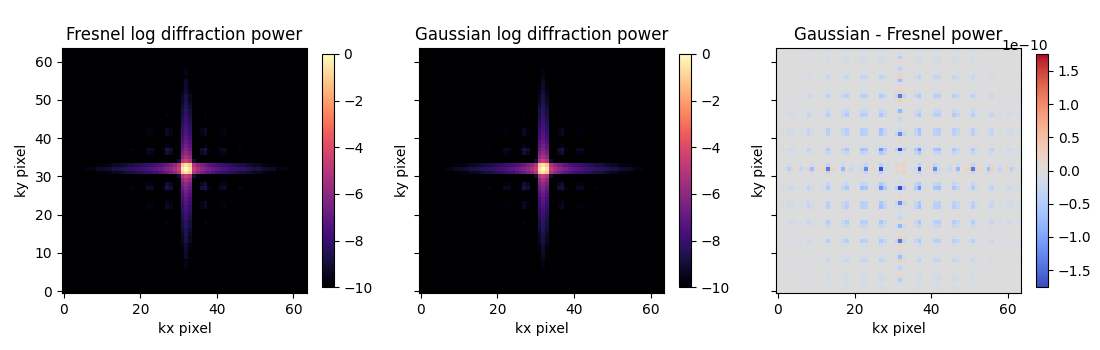

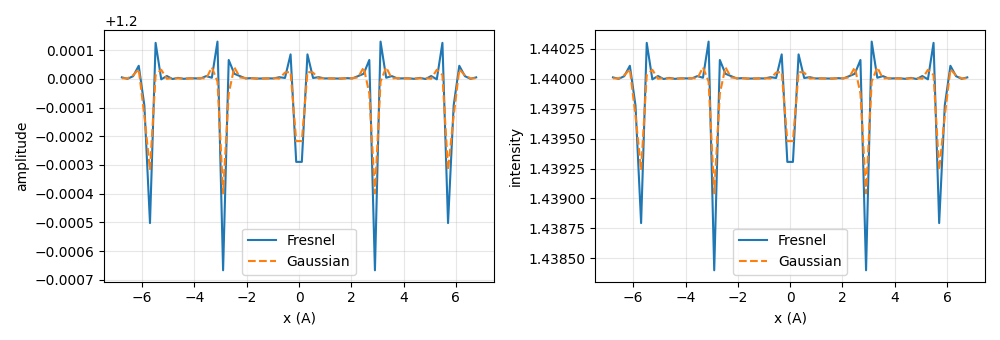

In [ ]:
def normalized_fft_power(field, *, window=True):
    data = np.asarray(field)
    if window:
        wy = np.hanning(data.shape[0])
        wx = np.hanning(data.shape[1])
        data = data * wy[:, None] * wx[None, :]
    power = np.abs(np.fft.fftshift(np.fft.fft2(data))) ** 2
    return power / np.max(power)


ref_power = normalized_fft_power(reference_crop)
gauss_power = normalized_fft_power(gaussian_crop)
power_diff = gauss_power - ref_power
limit = float(np.max(np.abs(power_diff)))
log_floor = 1e-10

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
panels = [
    (np.log10(np.maximum(ref_power, log_floor)), "Fresnel log diffraction power", "magma", None),
    (np.log10(np.maximum(gauss_power, log_floor)), "Gaussian log diffraction power", "magma", None),
    (power_diff, "Gaussian - Fresnel power", "coolwarm", limit),
]
for ax, (data, title, cmap, lim) in zip(axes, panels):
    kwargs = {}
    if lim is not None and lim > 0:
        kwargs.update(vmin=-lim, vmax=lim)
    im = ax.imshow(data, origin="lower", cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.set_xlabel("kx pixel")
    ax.set_ylabel("ky pixel")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
plt.show()

center = reference_crop.shape[0] // 2
x = np.asarray(grid.coords_1d[0])[x_crop]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(x, np.abs(reference_crop[center]), label="Fresnel")
axes[0].plot(x, np.abs(gaussian_crop[center]), "--", label="Gaussian")
axes[0].set_xlabel("x (A)")
axes[0].set_ylabel("amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(x, np.abs(reference_crop[center]) ** 2, label="Fresnel")
axes[1].plot(x, np.abs(gaussian_crop[center]) ** 2, "--", label="Gaussian")
axes[1].set_xlabel("x (A)")
axes[1].set_ylabel("intensity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Timing Summary

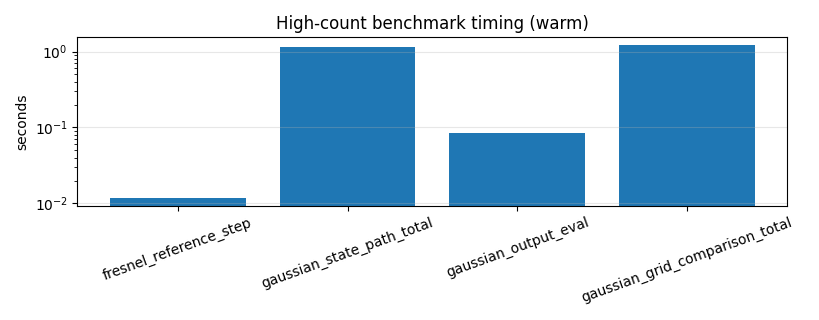

In [ ]:
timings_for_plot = warm_timings or first_timings
fig, ax = plt.subplots(figsize=(8.2, 3.2))
keys = [
    "fresnel_reference_step",
    "gaussian_state_path_total",
    "gaussian_output_eval",
    "gaussian_grid_comparison_total",
]
ax.bar(keys, [timings_for_plot[key] for key in keys])
ax.set_yscale("log")
ax.set_ylabel("seconds")
ax.set_title("High-count benchmark timing" + (" (warm)" if warm_timings else " (first run)"))
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()